# Ce abundances in the halo

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import paths
from utils import get_bin_centers, binned_quantiles, apply_alpha_cut
from plotting import get_color_list
from mwm_sample import abundance_ratio

plt.style.use(paths.styles / 'notebook.mplstyle')

In [45]:
mwm_rgb = pd.read_csv(paths.data / 'MWM' / 'MWM_RGB.csv')
mwm_rgb

/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_87404/610113364.py:1: DtypeWarning: Columns (44) have mixed types. Specify dtype option on import or set low_memory=False.
  mwm_rgb = pd.read_csv(paths.data / 'MWM' / 'MWM_RGB.csv')



,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,phot_rp_mean_mag,ruwe,z_max,Rg,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr
0,54381405,NaN,421506067509558016,421506067510359808,369831290,16384,tic_v8,25,27021597850724078,4291440182,...,11.174816,1.058355,NaN,NaN,-0.325526,0.017186,0.000862,-0.000862,0.343573,0.342712
1,54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,...,10.450673,1.183852,0.205899,8.531358,-0.263113,0.010890,-0.013271,0.013271,0.260731,0.274003
2,54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,...,10.509450,1.051452,0.107297,8.766076,-0.241018,0.079030,0.003839,-0.003839,0.323887,0.320048
3,54381968,2M00220667+5639444,421558740986710784,421558740986710784,403316795,16025,gaia_dr3_source,31,63050394783222492,4291878364,...,13.976727,1.005231,NaN,NaN,-0.112523,0.228345,-0.020530,0.020530,0.320339,0.340869
4,54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,...,10.972714,0.981112,0.178598,8.755011,0.061913,0.190950,0.048523,-0.048523,0.177560,0.129037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176718,129060852,2M09102693-4801480,5326834219657160960,5326834219657160960,355667744,171467,gaia_dr3_source,31,63050395876140056,5802252790,...,NaN,NaN,NaN,NaN,-0.451700,-0.091048,0.024848,-0.024848,0.385501,0.360653
176719,129060869,2M13544004-6145050,5867067884895910016,5867067884895910016,381878669,184774,gaia_dr3_source,31,63050396109299295,5632215191,...,NaN,NaN,NaN,NaN,0.251323,0.168338,0.085263,-0.085263,0.002278,-0.082985
176720,129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,...,NaN,NaN,NaN,NaN,-0.363648,-0.118817,-0.011611,0.011611,0.233220,0.244831
176721,129060885,2M08333243-3911278,5529360241405866752,5529360241405866752,185021879,160694,gaia_dr3_source,31,63050395950945615,5800869040,...,NaN,NaN,NaN,NaN,-0.176592,0.063355,-0.014382,0.014382,0.225565,0.239947


In [46]:
# Impose higher S/N, upper limits from Shetrone et al. (2025)
def ce_upper_limit(teff, snr):
    return -0.93 + 0.51*(teff/1000) - 1.84*(np.log10(snr)) + 0.174*(np.log10(snr))**2

ce_limits = mwm_rgb[
    (mwm_rgb['snr'] > 150) &
    (mwm_rgb['ce_h'] - mwm_rgb['e_ce_h'] < ce_upper_limit(mwm_rgb['teff'], mwm_rgb['snr']))
].copy()

mwm_rgb = mwm_rgb[
    (mwm_rgb['snr'] > 150) &
    (mwm_rgb['ce_h'] - mwm_rgb['e_ce_h'] > ce_upper_limit(mwm_rgb['teff'], mwm_rgb['snr']))
].copy()

In [47]:
mwm_rgb['ce_mn'], mwm_rgb['e_ce_mn'] = abundance_ratio(mwm_rgb, 'ce', 'mn')
mwm_rgb['mg_mn'], mwm_rgb['e_mg_mn'] = abundance_ratio(mwm_rgb, 'mg', 'mn')
mwm_rgb['al_fe'], mwm_rgb['e_al_fe'] = abundance_ratio(mwm_rgb, 'al', 'fe')

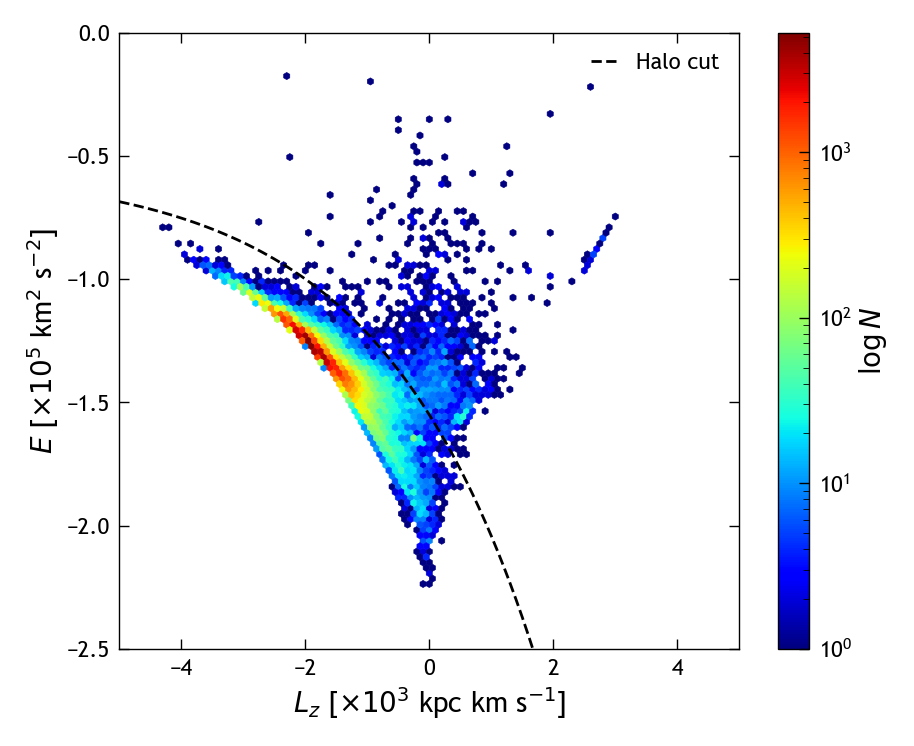

In [48]:
fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-5, 5, -2.5, 0.])
pcm = ax.hexbin(
    mwm_rgb['Lz']/1e3, mwm_rgb['E']/1e5, 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=np.sum,
    norm=LogNorm(),
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

def halo_ELz_cut(Lz):
    # return -0.035*(Lz + 5)**2 - 0.7
    return -0.55 - np.exp(Lz / 2.5)

Lz_arr = np.arange(-5, 5.1, 0.1)
ax.plot(Lz_arr, halo_ELz_cut(Lz_arr), 'k--', label='Halo cut')

ax.set_xlabel(r'$L_z$ [$\times10^3$ kpc km s$^{-1}$]')
ax.set_ylabel(r'$E$ [$\times 10^5$ km$^2$ s$^{-2}$]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

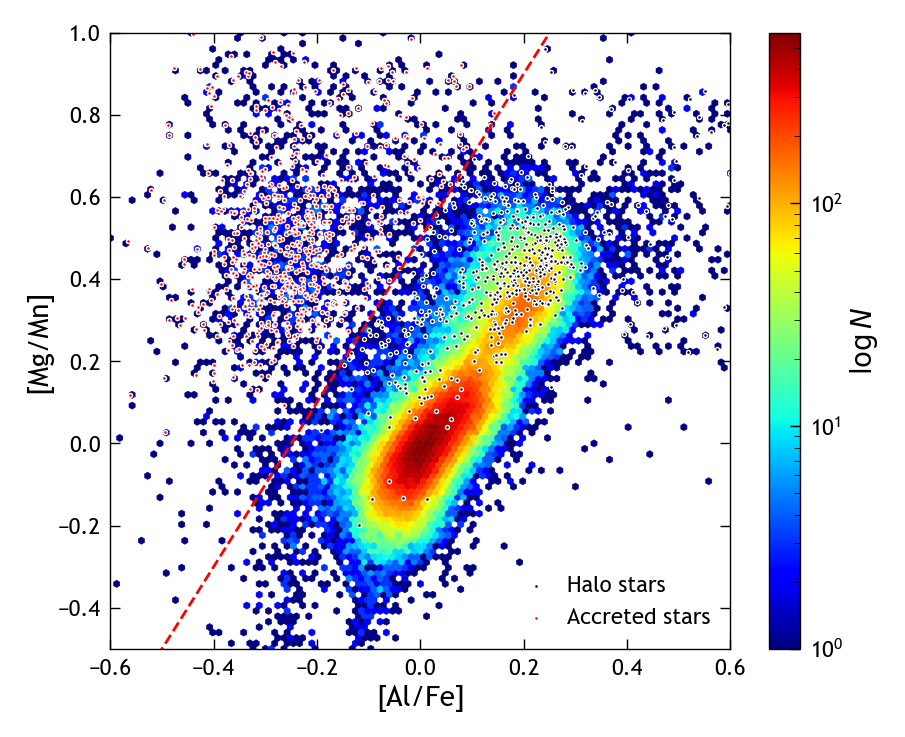

In [58]:
fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-0.6, 0.6, -0.5, 1])
pcm = ax.hexbin(
    mwm_rgb['al_fe'], mwm_rgb['mg_mn'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=np.sum,
    norm=LogNorm(),
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

mwm_halo = mwm_rgb[mwm_rgb['E']/1e5 > halo_ELz_cut(mwm_rgb['Lz']/1e3)]
mwm_disk = mwm_rgb[mwm_rgb['E']/1e5 < halo_ELz_cut(mwm_rgb['Lz']/1e3)]
ax.scatter(mwm_halo['al_fe'], mwm_halo['mg_mn'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='k', label='Halo stars')

def accreted_boundary(alfe):
    return 0.5 + 2*alfe

alfe_arr = np.arange(-0.6, 0.5, 0.1)
ax.plot(alfe_arr, accreted_boundary(alfe_arr), 'r--')

mwm_accreted = mwm_halo[mwm_halo['mg_mn'] > accreted_boundary(mwm_halo['al_fe'])]
mwm_halo_in_situ = mwm_halo[mwm_halo['mg_mn'] < accreted_boundary(mwm_halo['al_fe'])]
ax.scatter(mwm_accreted['al_fe'], mwm_accreted['mg_mn'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='r', label='Accreted stars')

ax.set_xlabel('[Al/Fe]')
ax.set_ylabel('[Mg/Mn]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

In [50]:
mg_coeffs = [0.38, 0.58, -5.17, 1.116]
fe_coeffs = [-1.88, 0.44, -1.91, 0.273]
ce_coeffs = [-0.93, 0.51, -1.84, 0.174]

def detection_limits(teff, snr, coeffs):
    return coeffs[0] + coeffs[1]*(teff/1000) + coeffs[2]*(np.log10(snr)) + coeffs[3]*(np.log10(snr))**2

[-3.292 -3.234 -3.176 -3.118 -3.06  -3.002 -2.944 -2.886 -2.828 -2.77
 -2.712 -2.654 -2.596 -2.538 -2.48 ]
[-1.976 -1.925 -1.874 -1.823 -1.772 -1.721 -1.67  -1.619 -1.568 -1.517
 -1.466 -1.415 -1.364 -1.313 -1.262]


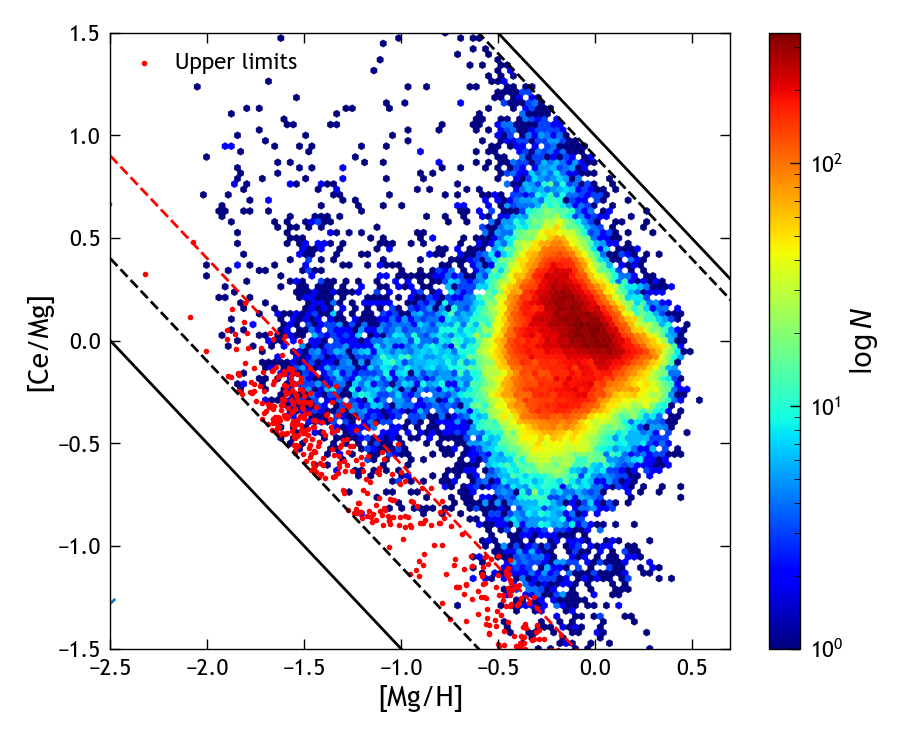

In [55]:
fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-2.5, 0.7, -1.5, 1.5])
pcm = ax.hexbin(
    mwm_rgb['mg_h'], mwm_rgb['ce_mg'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=np.sum,
    norm=LogNorm(),
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

# ax.scatter(mwm_halo['mg_h'], mwm_halo['ce_mg'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='k', label='Halo stars')
ax.scatter(ce_limits['mg_h'], ce_limits['ce_mg'], c='r', s=1, label='Upper limits')

# Indicate abundance upper limits
teff_arr = np.arange(3800, 5300, 100)
ax.plot(detection_limits(teff_arr, 100, mg_coeffs), detection_limits(teff_arr, 100, ce_coeffs))
print(detection_limits(teff_arr, 100, mg_coeffs))
print(detection_limits(teff_arr, 100, ce_coeffs))

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k--') # edge of stars flagged bad
ax.plot(mgh_arr, -1.6 - mgh_arr, 'r--') # indicates region of upper limits (manual)
ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k--') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

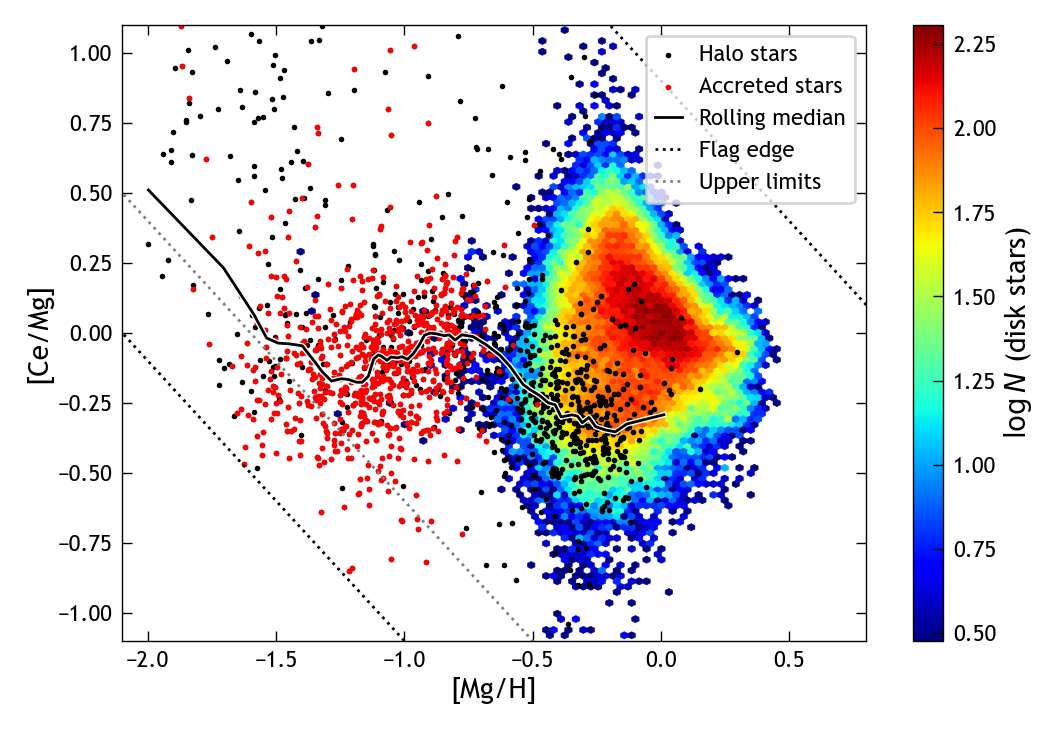

In [79]:
fig, ax = plt.subplots(figsize=(6, 4))

logsum = lambda x: np.log10(np.sum(x))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-2.1, 0.8, -1.1, 1.1], mincnt=3)
pcm = ax.hexbin(
    mwm_disk['mg_h'], mwm_disk['ce_mg'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=logsum,
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$ (disk stars)')

ax.scatter(mwm_halo['mg_h'], mwm_halo['ce_mg'], rasterized=True, s=1, c='k', label='Halo stars')
ax.scatter(mwm_accreted['mg_h'], mwm_accreted['ce_mg'], rasterized=True, s=1, c='r', label='Accreted stars')

# Rolling median
sorted_data = mwm_halo.sort_values('mg_h')[['mg_h', 'ce_mg']]
rolling_medians = sorted_data.rolling(
    100, min_periods=30, step=30, on='mg_h', center=True
).median()
ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'w-', linewidth=2)
ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'k-', label='Rolling median')

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
# ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k:', label='Flag edge') # edge of stars flagged bad
ax.plot(mgh_arr, -1.6 - mgh_arr, color='gray', ls=':', label='Upper limits') # indicates region of upper limits (manual)
# ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k:') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend(frameon=True, loc='upper right')

plt.show()

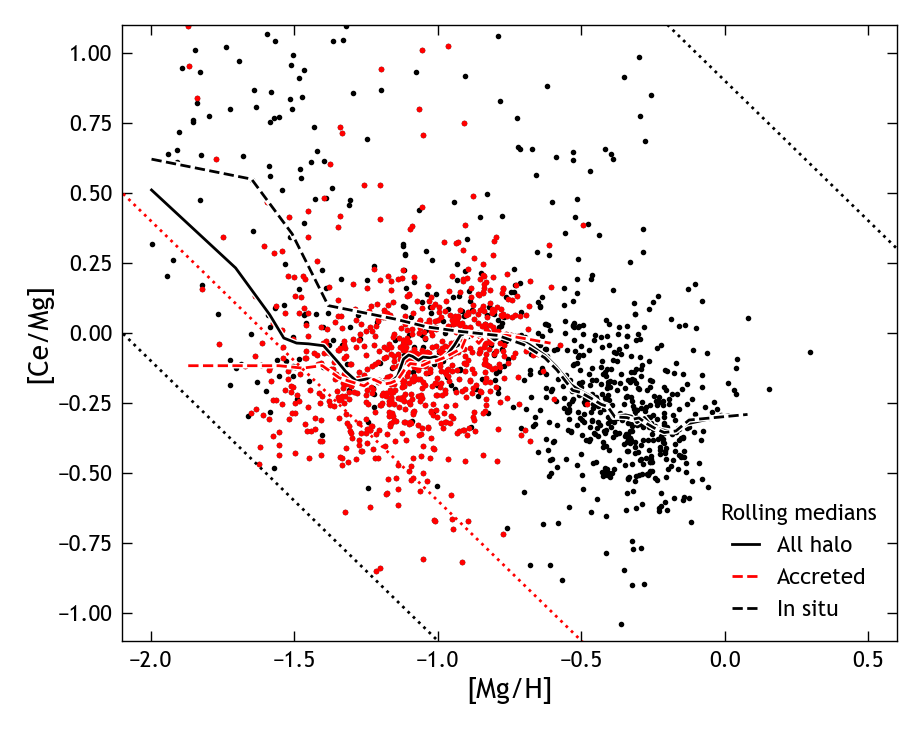

In [53]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(mwm_halo['mg_h'], mwm_halo['ce_mg'], rasterized=True, s=1, c='k')
ax.scatter(mwm_accreted['mg_h'], mwm_accreted['ce_mg'], rasterized=True, s=1, c='r')

# Rolling median
fmt = ['k-', 'r--', 'k--']
labels = ['All halo', 'Accreted', 'In situ']
for i, data in enumerate([mwm_halo, mwm_accreted, mwm_halo_in_situ]):
    sorted_data = data.sort_values('mg_h')[['mg_h', 'ce_mg']]
    rolling_medians = sorted_data.rolling(
        100, min_periods=30, step=30, on='mg_h', center=True
    ).median()
    ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], 'w-', linewidth=2)
    ax.plot(rolling_medians['mg_h'], rolling_medians['ce_mg'], fmt[i], label=labels[i])

# Indicate grid edges
mgh_arr = np.arange(-2.5, 1.25, 0.25)
# ax.plot(mgh_arr, -2.5 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, -2.1 - mgh_arr, 'k:') # edge of stars flagged bad
ax.plot(mgh_arr, -1.6 - mgh_arr, 'r:') # indicates region of upper limits (manual)
# ax.plot(mgh_arr, 1 - mgh_arr, 'k-') # hard grid edge
ax.plot(mgh_arr, 0.9 - mgh_arr, 'k:') # edge of stars flagged bad

ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((-2.1, 0.6))
ax.set_ylim((-1.1, 1.1))
ax.legend(title='Rolling medians')

plt.show()

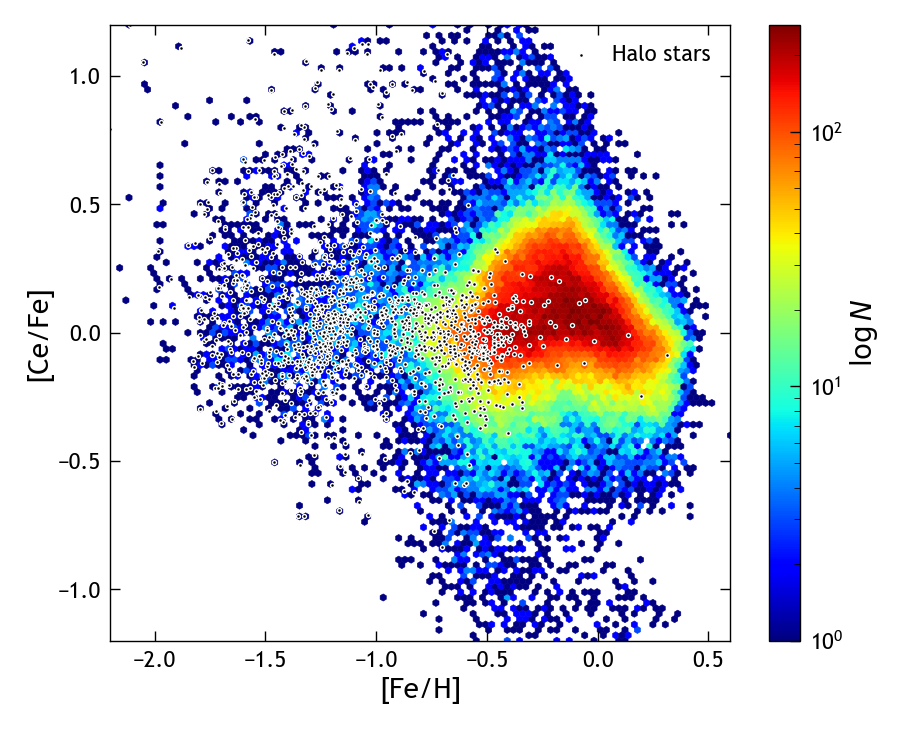

In [54]:
fig, ax = plt.subplots(figsize=(5, 4))

kwargs = dict(gridsize=100, cmap='jet', linewidths=0.2, extent=[-2.2, 0.6, -1.2, 1.2])
pcm = ax.hexbin(
    mwm_rgb['fe_h'], mwm_rgb['ce_fe'], 
    C=np.ones(mwm_rgb.shape[0]),
    reduce_C_function=np.sum,
    norm=LogNorm(),
    **kwargs
)
fig.colorbar(pcm, ax=ax, label=r'$\log N$')

ax.scatter(mwm_halo['fe_h'], mwm_halo['ce_fe'], rasterized=True, edgecolors='w', linewidths=0.5, s=2, c='k', label='Halo stars')

ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Ce/Fe]')
ax.set_xlim(kwargs['extent'][:2])
ax.set_ylim(kwargs['extent'][2:])
ax.legend()

plt.show()

Can I select halo stars that aren't in LMC, SMC, or other dwarfs? Could also try to exclude GSE.